# WCC: transit photometry of a bright host star (exoplanets)

Transit follow-up asks for millimagnitude-or-better precision on stars that are bright by
survey standards. On the Wide-field Context Camera (WCC) the limit is set on one side by photon
noise and on the other by the shallow well of the CMOS sensor. This notebook uses `wcc_etc` to ask
**what per-point precision WCC reaches on a transit host as a function of its magnitude, and how
the exposure must be split into reads to keep the star unsaturated.**

Install: [repository setup](../../README.md); browse the [gallery index](../README.md).

**At a glance** · Starter · Package: `wcc_etc`

- **Question:** the bold science question above; aim for one observing decision from the main comparison plot.
- **Prerequisite:** installed [gallery environment](../../README.md), basic Python and magnitudes/SNR.
- **Cost:** scalar/spectral calculations, normally seconds to minutes; cache downloads can add time.
- **First edit:** the Parameters cell below. Restart Kernel and Run All after each change.
- **Output:** plotted comparison plus printed achieved metrics/status.
- **Caveat:** ETC model assumptions and the source template determine the answer; exposure excludes operational overhead.

Section introductions describe the original defaults; the Parameters cell and current outputs are authoritative after edits.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wcc_etc
from wcc_etc import Simulation, get_scene, TransitModel, LightCurveSimulator

wcc_etc.set_wcc_style()

## Parameters
Change these inputs first; leave the calculation cells intact.


In [2]:
HOST_MAG = 16.0        # SDSS r, AB; read-planning example
DEMO_MAG = 19.0        # separate single-read light-curve demonstration
EXPOSURE = 60.0        # seconds per cadence point
RADIUS_RATIO = 0.1
PERIOD = 1.0           # days
A_OVER_R = 10.0
INCLINATION = 88.0     # degrees


## 1. Build the host star and the transit model

A K2V host at r = 16 on the in-focus IMX455 in the r band, normalized explicitly in SDSS r (AB)
(`get_scene` otherwise normalizes to Johnson V Vega whatever the observing filter is), and a hot
Jupiter with Rp/R* = 0.1, P = 1 d, a/R* = 10, i = 88 deg. The depth is $(R_p/R_*)^2$ and the
duration $T_{14}$ follows from the geometry; both are computed below and reused in section 4.

`choose_reads` returns the smallest tested read split whose per-frame image has no saturated pixel, or an
explicit failure. Saturated rows are marked and their SNR is not a valid precision.

In [3]:
sim = Simulation.from_sensorfilter("zwo:r", get_scene("K2V", mag=HOST_MAG, bandpass="sdss_r", magsys="abmag"))
planet = TransitModel(t0=0.0, per=PERIOD, rp=RADIUS_RATIO, a=A_OVER_R, inc=INCLINATION)
inc = np.radians(planet.inc)
b = planet.a * np.cos(inc)
t14_h = 24 * planet.per / np.pi * np.arcsin(np.sqrt((1 + planet.rp) ** 2 - b ** 2) / (planet.a * np.sin(inc)))
print(f"depth (Rp/R*)^2 = {planet.rp ** 2:.2%}, impact parameter b = {b:.2f}, duration T14 = {t14_h:.2f} h\n")

t_exp = EXPOSURE
READS = (1, 2, 3, 6, 12, 30, 60, 120, 300, 600)

def choose_reads(sim, t, reads=READS):
    """Smallest read count with no saturated pixel in the per-frame image; (None, last result) if none works."""
    for n in reads:
        r = sim.get_image_snr(t, n_reads=n, warn=False)
        if not r["saturated"]:
            return n, r
    return None, r

print(f"{'reads':>5} {'frame s':>7} {'sat px':>6} {'SNR':>5} {'ppm/point':>9}  status")
for n in (1, 6, 60):
    r = sim.get_image_snr(t_exp, n_reads=n, warn=False)
    ppm = "-" if r["saturated"] else f"{1e6 / r['snr']:.0f}"
    print(f"{n:5d} {t_exp / n:7.1f} {r['n_saturated']:6d} {r['snr']:5.0f} {ppm:>9}  "
          f"{'saturated: not a valid precision' if r['saturated'] else 'ok'}")
n16, r16 = choose_reads(sim, t_exp)
if n16 is None:
    print(f"No unsaturated read split at r={HOST_MAG:g} among {READS}; no valid precision.")
else:
    print(f"Smallest tested split at r={HOST_MAG:g}: {n16} reads of {t_exp/n16:g} s; {1e6/r16['snr']:.0f} ppm/point")


depth (Rp/R*)^2 = 1.00%, impact parameter b = 0.35, duration T14 = 0.80 h

reads frame s sat px   SNR ppm/point  status
    1    60.0     13   892         -  saturated: not a valid precision
    6    10.0      0   890      1123  ok
   60     1.0      0   875      1143  ok
Smallest tested split at r=16: 6 reads of 10 s; 1123 ppm/point


[wcc_etc] note: even n_pixels is rounded up by 1 to center the PSF peak (shown once).


## 2. A simulated transit

One 5.8 h window of 60 s exposures around mid-transit, with the per-point scatter set by the ETC
SNR. `LightCurveSimulator` uses a single read per point, so the host is set to r = 19 here, the
brightest whole-magnitude K2V that stays unsaturated in a 60 s single-read frame (asserted here,
see also the table in section 3).

LightCurve(n=346, snr=222.8, flux_err=0.00449, exptime=60s)


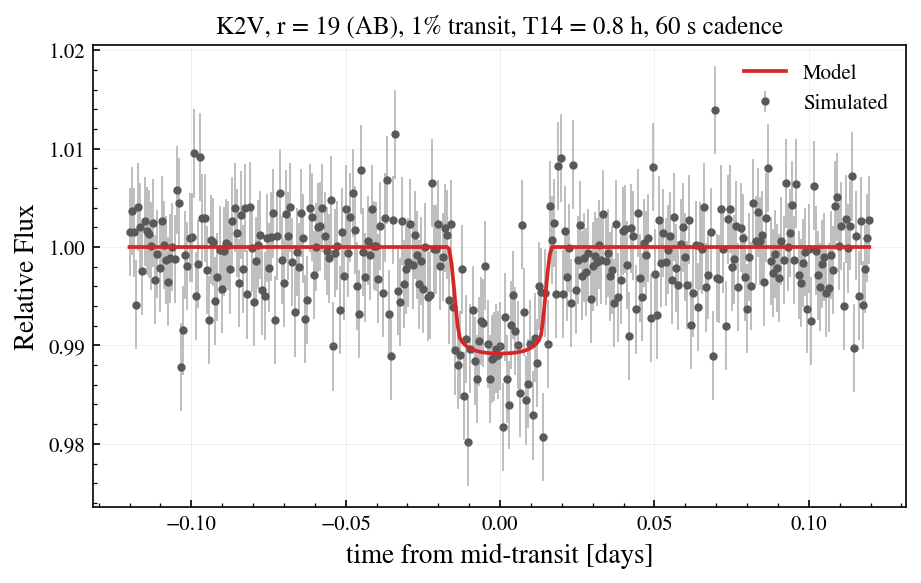

In [4]:
sim.update(source__mag=DEMO_MAG)
assert not sim.get_image_snr(t_exp, n_reads=1, warn=False)["saturated"], "DEMO_MAG saturates a single read: use a fainter demonstration star or shorter EXPOSURE"
time = np.arange(-0.12, 0.12, t_exp / 86400)   # days, mid-exposure
lc = LightCurveSimulator(sim, planet).simulate(time, t_exp, seed=1)
print(lc)
lc.plot()
plt.xlabel("time from mid-transit [days]")
plt.title(f"K2V, r = {DEMO_MAG:g} (AB), {planet.rp ** 2:.0%} transit, T14 = {t14_h:.1f} h, {t_exp:g} s cadence")
plt.show()

## 3. Precision versus host magnitude

Per-point precision for 60 s exposures, the same binned to 1 hour (a precision, not a detection
significance), and the smallest number of reads that keeps every frame below the sensor well
depth. Hosts for which no split in the list works are marked and left off the plot. The ETC has no
readout model: every split assumes negligible dead time between reads, and sub-second frames
exceed the full-frame 16-bit rate of the IMX455 (a few frames per second), so they need a windowed
readout. Depth lines use $(R_p/R_*)^2$ with explicit radii.

r (AB) reads frame s   SNR ppm/60 s ppm/hour  status


  11.0   600    0.10  8903      112       15  ok


  12.0   300    0.20  5615      178       23  ok


  13.0   120    0.50  3543      282       36  ok


  14.0    60    1.00  2234      448       58  ok


...

  17.0     3   20.00   561     1781      230  ok


  18.0     1   60.00   354     2822      364  ok


  19.0     1   60.00   223     4489      579  ok


  20.0     1   60.00   139     7176      926  ok


  21.0     1   60.00    86    11615     1499  ok


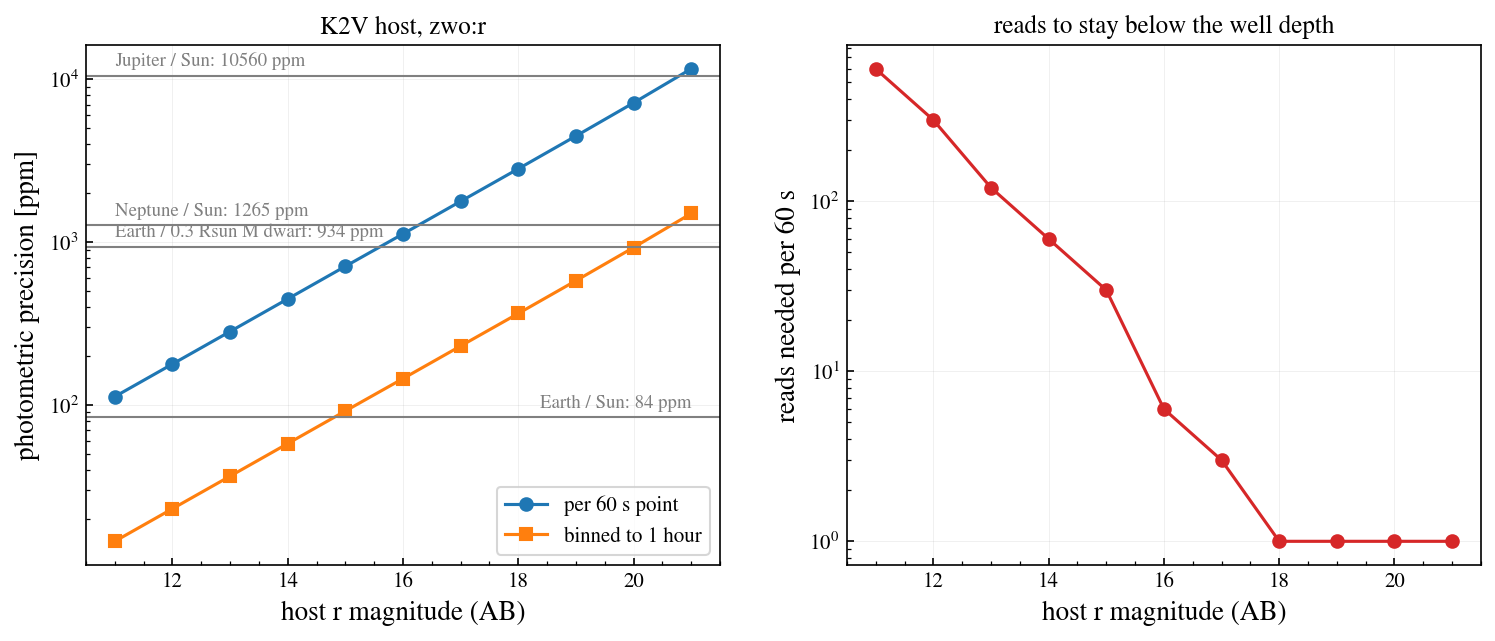

In [5]:
from astropy.constants import R_jup, R_earth, R_sun

depths = {  # (Rp/R*)^2 with explicit radii
    "Jupiter / Sun": float((R_jup / R_sun) ** 2),
    "Neptune / Sun": float((3.88 * R_earth / R_sun) ** 2),
    "Earth / 0.3 Rsun M dwarf": float((R_earth / (0.3 * R_sun)) ** 2),
    "Earth / Sun": float((R_earth / R_sun) ** 2),
}
mags = np.arange(11, 21.5, 1.0)
rows = []
print(f"{'r (AB)':>6} {'reads':>5} {'frame s':>7} {'SNR':>5} {'ppm/60 s':>8} {'ppm/hour':>8}  status")
for m in mags:
    sim.update(source__mag=float(m))
    n, r = choose_reads(sim, t_exp)
    ok = n is not None
    ppm = 1e6 / r["snr"] if ok else np.nan
    rows.append((m, n if ok else np.nan, ppm, ppm / np.sqrt(3600 / t_exp)))
    print(f"{m:6.1f} {str(n if ok else '-'):>5} {t_exp / n if ok else np.nan:7.2f} {r['snr'] if ok else np.nan:5.0f} "
          f"{ppm:8.0f} {rows[-1][3]:8.0f}  {'ok' if ok else f'saturated at every split up to {READS[-1]} reads'}")
mags, n_needed, ppm_point, ppm_hour = map(np.array, zip(*rows))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax.semilogy(mags, ppm_point, "o-", label=f"per {t_exp:g} s point")
ax.semilogy(mags, ppm_hour, "s-", label="binned to 1 hour")
for name, d in depths.items():
    right = name == "Earth / Sun"                     # keep labels off the curves
    ax.axhline(d * 1e6, color="0.5", lw=1)
    ax.text(mags[-1] if right else mags[0], d * 1.15e6, f"{name}: {d * 1e6:.0f} ppm", color="0.5",
            ha="right" if right else "left", fontsize=9)
ax.set(xlabel="host r magnitude (AB)", ylabel="photometric precision [ppm]", title="K2V host, zwo:r")
ax.legend(loc="lower right")
ax2.semilogy(mags, n_needed, "o-", color="C3")
ax2.set(xlabel="host r magnitude (AB)", ylabel=f"reads needed per {t_exp:g} s", title="reads to stay below the well depth")
plt.show()

## 4. Transit detection significance

For a single transit of duration $T_{14}$ observed at 60 s cadence with a finite out-of-transit
baseline, the depth uncertainty is
$\sigma_\delta = \sigma_\mathrm{point}\sqrt{1/N_\mathrm{in} + 1/N_\mathrm{out}}$, with
$N_\mathrm{in} = T_{14}/t_\mathrm{exp}$ and $N_\mathrm{out}$ the remaining points in the same
5.8 h window as section 2. This assumes white noise, equal noise in and out of transit, a known
ephemeris and no systematics (a perfect baseline model), so it is an upper bound on the
significance. The binned precision of section 3 is not itself a detection significance.

In [6]:
window_h = 24 * (time[-1] - time[0] + t_exp / 86400)
n_in = t14_h * 3600 / t_exp
n_out = (window_h - t14_h) * 3600 / t_exp
assert n_in > 0 and n_out > 0, "Transit must fit inside the observation window with an out-of-transit baseline"
print(f"T14 = {t14_h:.2f} h in a {window_h:.1f} h window: N_in = {n_in:.0f}, N_out = {n_out:.0f} points of {t_exp} s\n")
names = ["Jupiter / Sun", "Neptune / Sun", "Earth / Sun"]
print(f"{'r (AB)':>6} {'sigma_depth ppm':>15}  " + "  ".join(f"{k:>13s}" for k in names))
for m, s in zip(mags, ppm_point):
    if not np.isfinite(s):
        print(f"{m:6.1f} {'-':>15}  no valid read split")
        continue
    sd = s * np.sqrt(1 / n_in + 1 / n_out)
    print(f"{m:6.1f} {sd:15.0f}  " + "  ".join(f"{depths[k] * 1e6 / sd:8.1f} sigma" for k in names))

T14 = 0.80 h in a 5.8 h window: N_in = 48, N_out = 298 points of 60.0 s

r (AB) sigma_depth ppm  Jupiter / Sun  Neptune / Sun    Earth / Sun
  11.0              17     604.2 sigma      72.4 sigma       4.8 sigma
  12.0              28     381.0 sigma      45.7 sigma       3.0 sigma
  13.0              44     240.4 sigma      28.8 sigma       1.9 sigma
  14.0              70     151.6 sigma      18.2 sigma       1.2 sigma
  15.0             111      95.6 sigma      11.5 sigma       0.8 sigma
  16.0             175      60.4 sigma       7.2 sigma       0.5 sigma
  17.0             277      38.1 sigma       4.6 sigma       0.3 sigma
  18.0             439      24.0 sigma       2.9 sigma       0.2 sigma
  19.0             699      15.1 sigma       1.8 sigma       0.1 sigma
  20.0            1117       9.5 sigma       1.1 sigma       0.1 sigma
  21.0            1807       5.8 sigma       0.7 sigma       0.0 sigma


## Reference-run takeaway (original defaults)

**Historical baseline prose:** numerical values below describe the pre-review default run. Use the freshly printed values and plots for current results, especially where this revision corrects an estimator.

A K2V host at r = 16 (AB) gives about 1100 ppm per 60 s point in the r band, or 145 ppm when
binned to one hour; the binned number is a precision, not a detection significance. For the
0.8 h transit above with a 5 h out-of-transit baseline, white noise and a perfect baseline model,
the depth uncertainty at r = 16 is 175 ppm, so a Jupiter/Sun transit (1.06 %) is detected at
~60 sigma, a Neptune/Sun transit (0.13 %) at ~7 sigma, and an Earth/Sun transit (84 ppm) is
undetectable in one event (0.5 sigma; 3 sigma needs r < 12). An Earth around a 0.3 R_sun M dwarf
(930 ppm) is a Neptune/Sun-sized signal, not a 100 ppm one. The price of the fine 16.9 mas pixels
is a shallow effective well: a single 60 s read saturates any host brighter than r ~ 18, r = 16
needs 6 reads of 10 s, and hosts brighter than r ~ 14 need sub-second frames that also require a
windowed readout. Splitting into reads costs almost nothing in precision at these magnitudes
because the star, not read noise, dominates.

## Try this

1. Set HOST_MAG to 17. Compare the smallest tested read split and ppm/point.
2. Set RADIUS_RATIO to 0.05. Report the change in depth, duration and recovered light curve.

**Extension:** Explore defocus once the sensor/focus mode is validated; the light-curve API currently supports only one read per point.

Bring back one figure, the requested and achieved metric, an observing decision, and the main limitation.
